# Stock Price Prediction — EDA

understand data quality, structure and any patterns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

## 1. Load data

In [3]:
price_df = pd.read_csv('price.csv', parse_dates=['date'])
news_df = pd.read_csv('news.csv', parse_dates=['datetime'])

print(f"Price data: {price_df.shape[0]:,} rows × {price_df.shape[1]} columns")
print(f"News data:  {news_df.shape[0]:,} rows × {news_df.shape[1]} columns")

Price data: 1,687 rows × 7 columns
News data:  4,440 rows × 4 columns


## 2. Price data exploration

In [21]:
price_df.head()

,date,ticker,open,high,low,close,volume,daily_return
0,2023-11-13,AAPL,185.820007,186.029999,184.210007,184.800003,43627500,NaN
1,2023-11-14,AAPL,187.699997,188.110001,186.300003,187.440002,60108400,0.014286
2,2023-11-15,AAPL,187.850006,189.500000,187.779999,188.009995,53790500,0.003041
3,2023-11-16,AAPL,189.570007,190.960007,188.649994,189.710007,54412900,0.009042
4,2023-11-17,AAPL,190.250000,190.380005,188.570007,189.690002,50922700,-0.000105


In [4]:
# data types
print(price_df.dtypes)
print(f"\nDate range: {price_df['date'].min().date()} → {price_df['date'].max().date()}")
print(f"Tickers:    {sorted(price_df['ticker'].unique())}")

date      datetime64[ns]
ticker            object
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

Date range: 2023-11-13 → 2024-10-28
Tickers:    ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


In [8]:
# trading days per ticker
print(price_df.groupby('ticker')['date'].count().to_string())

ticker
AAPL     241
AMZN     241
GOOGL    241
META     241
MSFT     241
NVDA     241
TSLA     241


In [10]:
# missing values
print(price_df.isnull().sum())

date      0
ticker    0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


no missing data

In [11]:
# descriptive statistics
price_df[['open', 'high', 'low', 'close', 'volume']].describe().round(2)

,open,high,low,close,volume
count,1687.00,1687.00,1687.00,1687.00,1.687000e+03
mean,245.20,248.03,242.28,245.26,9.613876e+07
std,134.58,135.78,133.25,134.54,1.442287e+08
min,45.47,46.08,45.01,45.50,5.467500e+06
25%,158.19,160.53,156.54,159.06,2.076580e+07
50%,187.36,189.28,185.42,187.43,3.934310e+07
75%,371.49,374.44,368.85,372.86,8.306055e+07
max,598.22,602.95,589.96,595.94,1.142269e+09


data is right skewed since the mean is higher than the median. Middle spread, 50% of the data lies in the 25th and 75th percentile.

2.1 Closing price trends

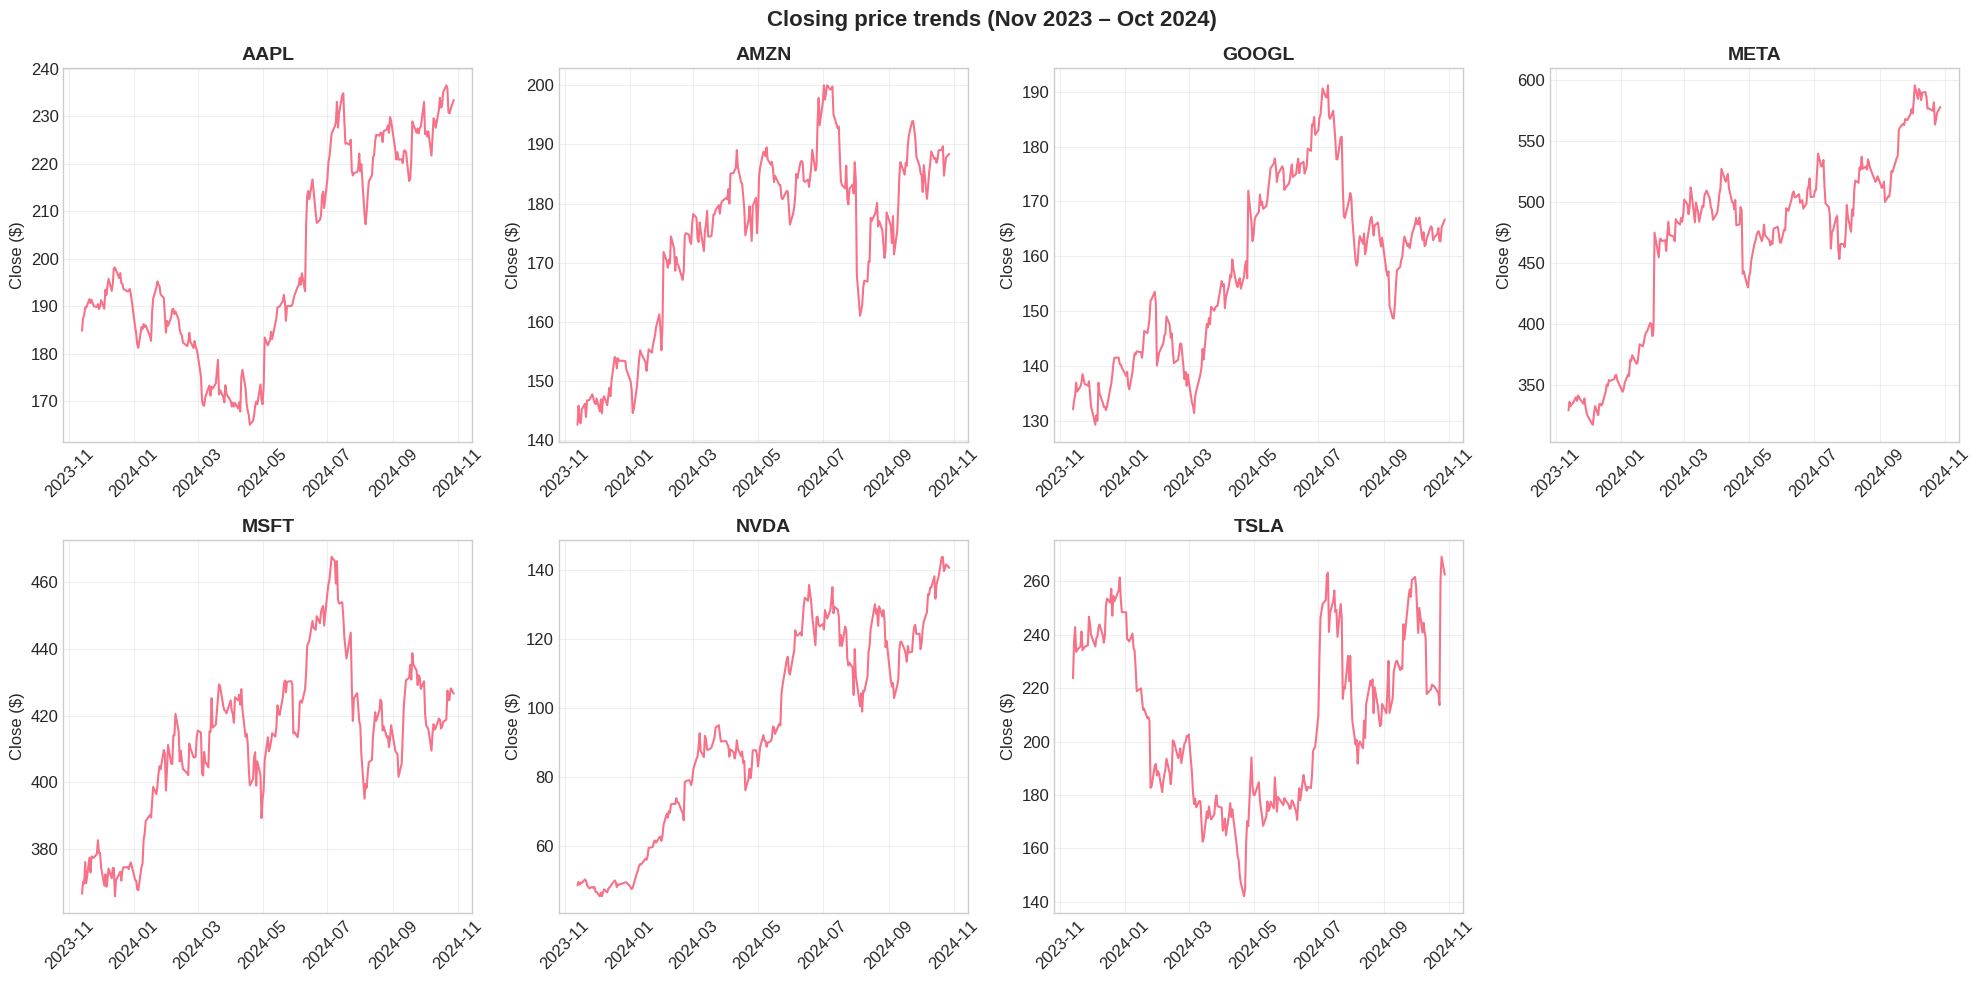

In [6]:
tickers = sorted(price_df['ticker'].unique())

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    data = price_df[price_df['ticker'] == ticker].sort_values('date')
    axes[i].plot(data['date'], data['close'], linewidth=1.5)
    axes[i].set_title(ticker, fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Close ($)')
    axes[i].grid(True, alpha=0.3)

axes[7].set_visible(False)
plt.suptitle('Closing price trends (Nov 2023 – Oct 2024)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

general growth with a local dip around april 2024 before correcting. TSLA shows high volatility unlike the rest. Almost all show typical cyclical growth patterns.

## 2.2 Daily returns distribution

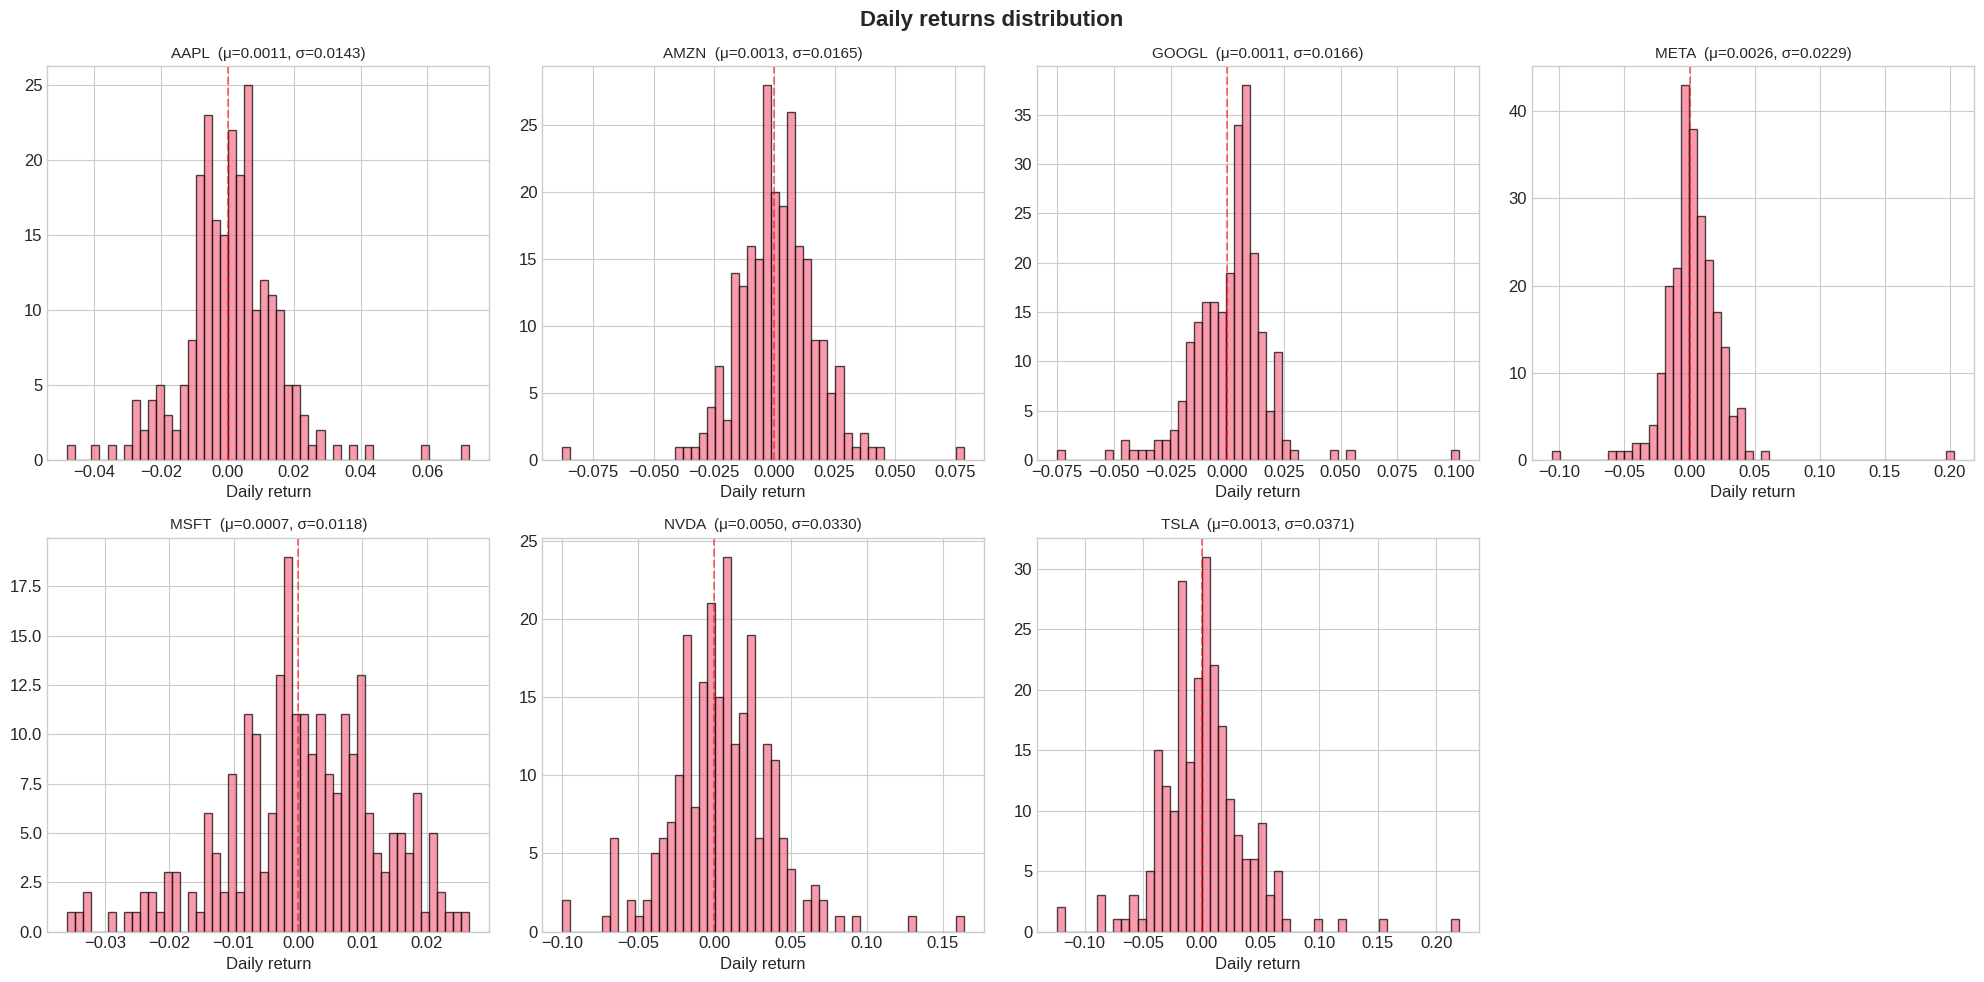

In [7]:
# compute daily returns per ticker
price_df = price_df.sort_values(['ticker', 'date'])
price_df['daily_return'] = price_df.groupby('ticker')['close'].pct_change()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    returns = price_df.loc[price_df['ticker'] == ticker, 'daily_return'].dropna()
    axes[i].hist(returns, bins=50, edgecolor='black', alpha=0.7)
    axes[i].axvline(x=0, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(
        f'{ticker}  (μ={returns.mean():.4f}, σ={returns.std():.4f})',
        fontsize=11
    )
    axes[i].set_xlabel('Daily return')

axes[7].set_visible(False)
plt.suptitle('Daily returns distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

positive daily returns in general with NVDA leading the group. MSFT has the lowest volatility with the tighest dristribution. Even though the distributions aproximate a normal one, the fat tails with outliers might prove predicting not so straight forward.

## 2.3 Volatility comparison

In [ ]:
# annualized volatility
vol_stats = price_df.groupby('ticker')['daily_return'].agg(['mean', 'std']).round(5)
vol_stats.columns = ['Mean Return', 'Std (Volatility)']
vol_stats = vol_stats.sort_values('Std (Volatility)', ascending=False)
vol_stats['Annualized Vol'] = (vol_stats['Std (Volatility)'] * np.sqrt(252)).round(4)
print(vol_stats.to_string())

        Mean Return  Std (Volatility)  Annualized Vol
ticker                                               
TSLA        0.00134           0.03705          0.5882
NVDA        0.00497           0.03300          0.5239
META        0.00260           0.02288          0.3632
GOOGL       0.00111           0.01657          0.2630
AMZN        0.00130           0.01645          0.2611
AAPL        0.00107           0.01428          0.2267
MSFT        0.00070           0.01177          0.1868


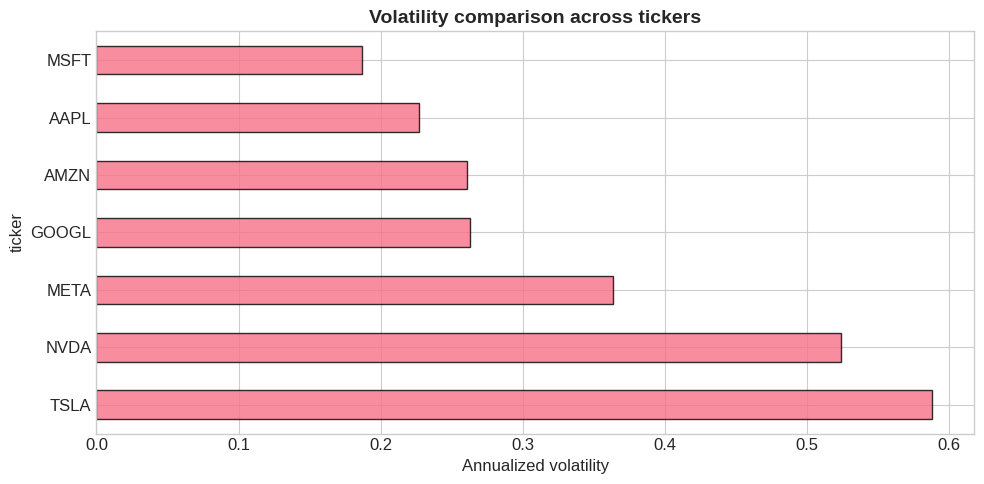

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
vol_stats['Annualized Vol'].plot(kind='barh', ax=ax, edgecolor='black', alpha=0.8)
ax.set_xlabel('Annualized volatility')
ax.set_title('Volatility comparison across tickers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

a better volatility viz

2.4 Price feature correlation

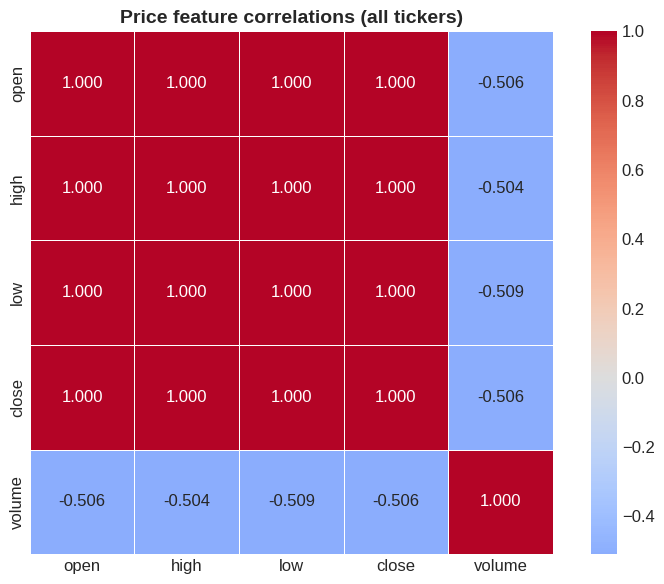

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = price_df[['open', 'high', 'low', 'close', 'volume']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Price feature correlations (all tickers)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

severe multicolinearity, including all features when predicting is redundant. Volume shows a negative correlation with all price features: as the price levels increase the traded volume tends to moderately decrease.

# 3. News data exploration

In [22]:
news_df.head()

,datetime,ticker,headline,summary,date
0,2024-10-29 18:07:48,AAPL,Apple Unveils the Redesigned Mac Mini,-- Apple overhauled the design of its Mac mini...,2024-10-29
1,2024-10-29 02:21:10,AAPL,Apple blocked from selling iPhone 16 in Indone...,TECH giant Apple will not be allowed to sell i...,2024-10-29
2,2024-10-28 14:05:22,AAPL,"Apple Rises on Apple Intelligence Rollout, New...",-- Apple unveiled its new iMac and said Apple ...,2024-10-28
3,2024-10-28 12:05:04,AAPL,Apple : How Apple developed the world’s first ...,apple stories Inside the Audio Lab: How Apple ...,2024-10-28
4,2024-10-28 11:02:06,AAPL,Apple launches the iPhone into the AI era with...,Apple is releasing a free software update that...,2024-10-28


In [ ]:
# data types
print(news_df.dtypes)
print(f"\nDate range: {news_df['datetime'].min()} → {news_df['datetime'].max()}")

datetime    datetime64[ns]
ticker              object
headline            object
summary             object
dtype: object

Date range: 2023-11-13 09:12:41 → 2024-10-29 19:34:15


In [17]:
# missing values
print(news_df.isnull().sum())

datetime    0
ticker      0
headline    0
summary     1
dtype: int64


In [18]:
# articles per ticker
print(news_df['ticker'].value_counts().to_string())

ticker
AMZN     941
AAPL     799
TSLA     794
NVDA     594
MSFT     535
META     391
GOOGL    386


## 3.1 News frequency over time

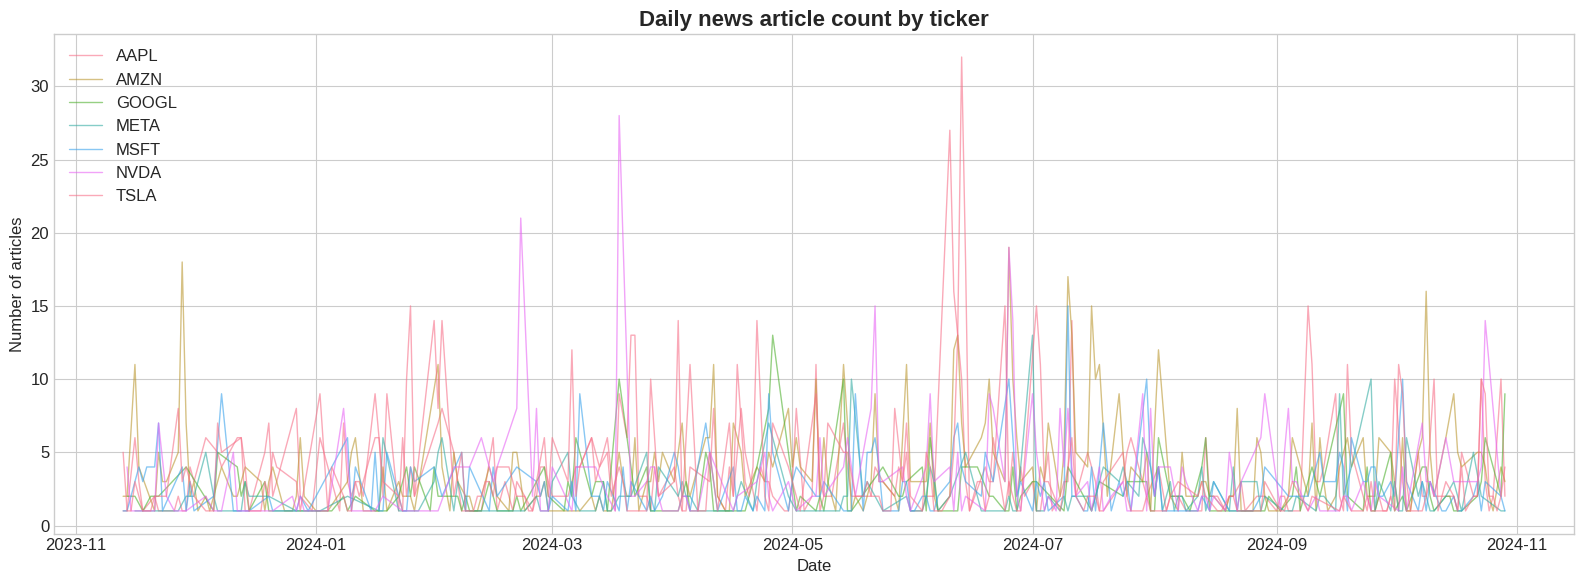

In [23]:
news_df['date'] = news_df['datetime'].dt.date
daily_news = news_df.groupby(['date', 'ticker']).size().reset_index(name='article_count')

fig, ax = plt.subplots(figsize=(16, 6))
for ticker in tickers:
    t = daily_news[daily_news['ticker'] == ticker]
    ax.plot(pd.to_datetime(t['date']), t['article_count'], alpha=0.6, label=ticker, linewidth=1)

ax.set_title('Daily news article count by ticker', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of articles')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

news article counts hover consistently in lower ranges except for various episodic spikes.